In [78]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import os
import sys
import json

module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from src.api import *
from src.utils import *
from src.const import *
from src.plots import *
from src.signal_providers.signal_manager import *
from src.news_providers.news_api_provider import *
from src.agents.news_filtering_agent import *
from src.agents.trading_agent import *
from src.ai_chat import *
from dotenv import load_dotenv

%load_ext autoreload
%autoreload 2

sns.set_theme(style="darkgrid")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [49]:
client = BasicApiClient()

In [50]:
client.create(
    [
        client.make_msg(
            "You are image descripto. Respond with json of this format: {'description': what you see, 'style': stylistics of the image, 'prompt': short description of charachter, style and cloth}",
            role=ROLE_SYSTEM,
        ),
        client.make_msg(
            text="What's in this image?",
            img="https://images.pexels.com/photos/45201/kitty-cat-kitten-pet-45201.jpeg?auto=compress&cs=tinysrgb&dpr=1&w=500",
        ),
    ],
    options={ "format": JSON_MODE },
)

'{\n  "description": "A small cream-colored kitten with bright blue eyes, propped up on a leopard-print fabric, gazing up with curiosity against a dark background.",\n  "style": "Close-up portrait photograph with warm lighting, shallow depth of field, focusing on the kitten’s facial features",\n  "prompt": "A cute cream-colored kitten with big blue eyes perched on a leopard-print cloth, photorealistic portrait style"\n}'

In [43]:
coin = "ETH"
cutoff = subtract_time(get_current_datetime(), days=0)
day_history, week_history, month_history = map_async(lambda: get_day_history(coin, cutoff), lambda: get_week_history(coin, cutoff), lambda: get_month_history(coin, cutoff))

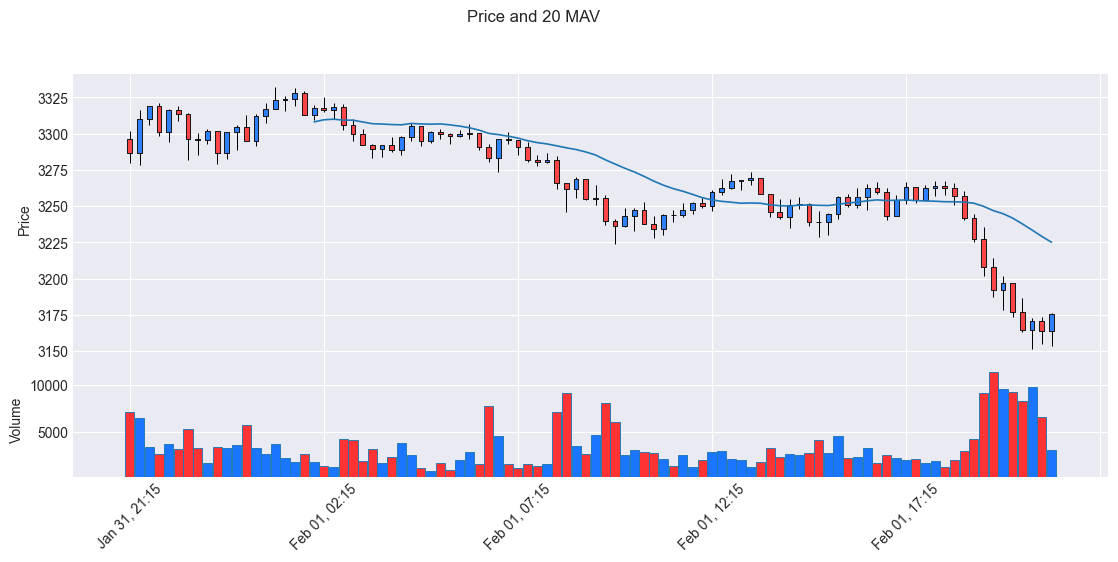

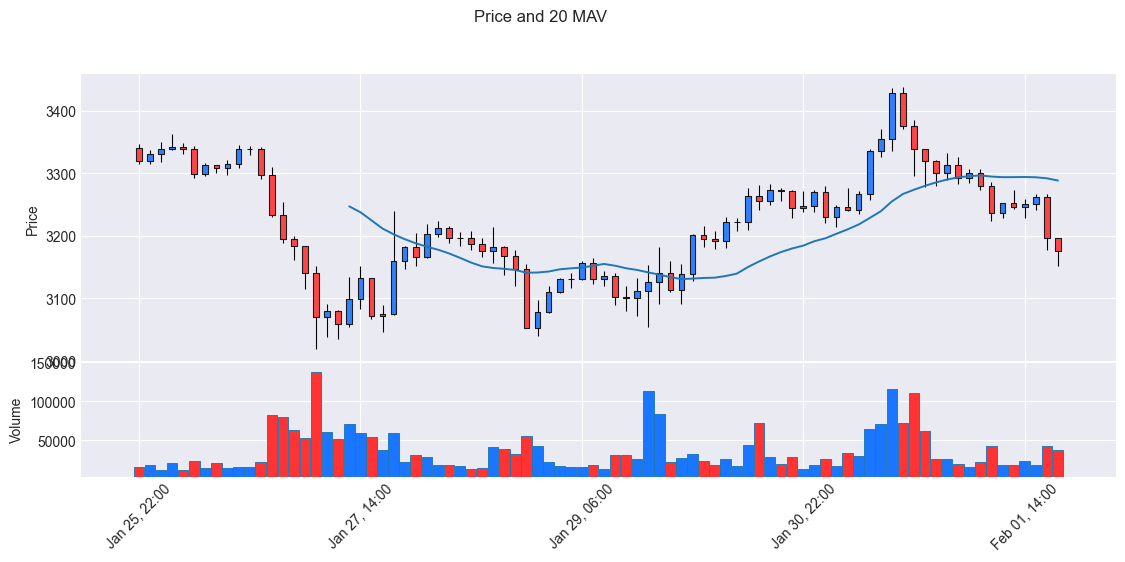

In [44]:
make_candlebars(day_history)
make_candlebars(week_history)

In [62]:
res = ai_client.create(
    [
        ai_client.make_msg(
            "You are professional trader",
            role=ROLE_SYSTEM,
        ),
        ai_client.make_msg(
            text='''What is shown on this image, what are the trends and prices? What do you expect prices to be in a week? If you were making a trade, what would you do?
            Respond with json of this format: 
                { 'complex_explanation': 'you deep analytics of the trend and possibilities', 
                  'simple_explanation': 'simple explanation of trends and predictions', 
                  'trade_suggestion': 'if you were making a trade, what would you do?',
                  'trade_explanation': 'reason about your decision, calculate potential profit and loss from the deal'
                  }
            ''',
            img=make_candlebars(week_history, useBuf=True),
        ),
    ],
    options={"format": JSON_MODE},
)

res

'{\n  "complex_explanation": "From a technical perspective, the chart shows a sharp drop from the mid-3300s down toward the 3000 level, followed by a rebound that briefly pushed above 3400 before turning lower again. The 20-period moving average (MAV) rose in late January, reflecting the rebound, but it has begun to flatten and slope downward as price has fallen below it. The relatively high trading volume near the recent top and on the subsequent decline suggests that sellers are regaining control. Support appears around 3000, while resistance sits near the 3400 level. Taken together, this indicates a short-term retracement lower, with buyers possibly stepping in near 3000 if that level is tested again.",\n  "simple_explanation": "Prices bounced from around 3000 to above 3400 but have dropped back below the 20-day average, signaling a possible short-term downtrend. Watch the 3000 level as support and 3400 as resistance over the coming week.",\n  "trade_suggestion": "Consider a short p

In [63]:
pretty_print_json(res)

{
    "complex_explanation": "From a technical perspective, the chart shows a sharp drop from the mid-3300s down toward the 3000 level, followed by a rebound that briefly pushed above 3400 before turning lower again. The 20-period moving average (MAV) rose in late January, reflecting the rebound, but it has begun to flatten and slope downward as price has fallen below it. The relatively high trading volume near the recent top and on the subsequent decline suggests that sellers are regaining control. Support appears around 3000, while resistance sits near the 3400 level. Taken together, this indicates a short-term retracement lower, with buyers possibly stepping in near 3000 if that level is tested again.",
    "simple_explanation": "Prices bounced from around 3000 to above 3400 but have dropped back below the 20-day average, signaling a possible short-term downtrend. Watch the 3000 level as support and 3400 as resistance over the coming week.",
    "trade_suggestion": "Consider a short

In [64]:
chat = AiChat()
chat.message("You are chatbot, respond to everything in RUSSIAN", role=ROLE_SYSTEM)
res = chat.message("Hello, how are you?")
print(res)

Привет! Спасибо, у меня всё хорошо. Как у вас дела?


In [91]:
import requests

api_key = os.getenv("CRYPTOPANIC_API_KEY")

url = "https://cryptopanic.com/api/v1/posts/"
params = {
    "auth_token": api_key,
    "public": "true",
    "currencies": "XRP",
    #"kind": "news", # news or media
}



# Make the GET request
response = requests.get(url, params=params)

# Check if the request was successful
if response.status_code == 200:
    data = response.json()
    print("Latest Crypto News from CryptoPanic:")
    for post in data.get("results", []):
        print(f"- {post.get('title')}")
else:
    print(f"Error: {response.status_code} - {response.text}")


Latest Crypto News from CryptoPanic:
- Smart Investors Are Accumulating Remittix The 'XRP Killer' and Solana (SOL) As Price Awaits Solana ETF News
- XRP Ledger (XRPL) Eyes Next Amendment To Boost NFTs
- Whales Are Shifting Their Attention to Solana, Hedera, Lightchain AI, and XRP — What This Means
- XRP Market Update: $3.10 Breakout or Bust? Traders Hold Breath as Bears Tighten Grip
- ETH Outperforms, Gold hits ATH, Saylor on Forbes cover
- XRP News Today: XRP now achieves record monthly closing
- Ripple (XRP) May Be Headed for $15, But New Rival at $0.005625 Remains the Best Bet for a 30x ROI
- Ripple Price Analysis: XRP’s Bullish Momentum Weakens—Correction Ahead?
- XRP Regains Momentum Ahead Of FOMC Meeting; Analysts Predict Further Support For Ethereum Altcoin Rollblock
- Ripple (XRP) Faces New Competition as Rexas Finance (RXS) Hype Skyrockets
- Top Analyst Predicts XRP Price Surge To $70, Here’s How
- Grayscale Seeks Spot XRP ETF Listing on NYSE
- Will XRP Price Hit $4.4, With  M

In [92]:
from src.news_providers.tradingview_provider import TradingViewProvider

provider = TradingViewProvider()
provider.get_news("XRP")


[{'source': 'cryptopotato',
  'title': 'Ripple Price Analysis: XRP’s Bullish Momentum Weakens—Correction Ahead?',
  'description': 'Ripple has been facing a prolonged period of low market activity, leading to sideways movement and minimal volatility near the $3.2 level.However, emerging technical signals suggest that a potential correction may be on the horizon.XRP AnalysisBy ShayanThe Daily ChartXRP has steadily climbed toward the $3.2 resistance, a crucial supply zone that has historically posed challenges for buyers. This level is a major obstacle, requiring strong bullish momentum to be reclaimed.Meanwhile, price action has formed an ascending wedge, a pattern often associated with bearish reversals if the lower boundary is breached. Additionally, a bearish divergence between the price and the RSI indicator suggests that bullish momentum is fading, signaling the possibility of a pullback.The 4-Hour ChartIf XRP fails to sustain its current levels and breaks below the wedge’s lower b